TensorFlow version: 2.20.0
GPU available: []
       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

2026-09-25 15:30:47.807182: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Conv shape : (10000, 28, 28, 1) (2000, 28, 28, 1)
Flat shape : (10000, 784) (2000, 784)
Pixel range: 0.0 to 1.0


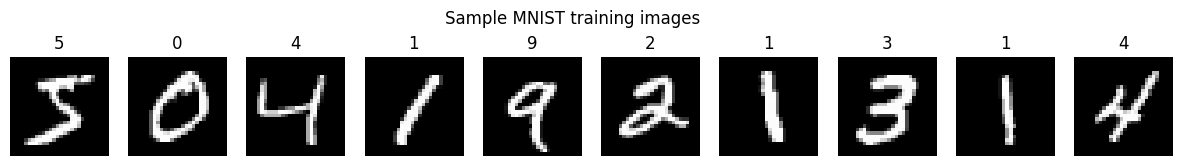

In [1]:
# ===== Step 1: Imports, Setup, Data Loading =====
import time
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.datasets import mnist

from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# ---- Load MNIST ----
(x_train_full, y_train_full), (x_test_full, y_test_full) = mnist.load_data()

# ---- Recommended lab subset: 10,000 train / 2,000 test ----
N_TRAIN, N_TEST = 10000, 2000
x_train, y_train = x_train_full[:N_TRAIN], y_train_full[:N_TRAIN]
x_test,  y_test  = x_test_full[:N_TEST],  y_test_full[:N_TEST]

# ---- Normalize [0,255] -> [0,1] ----
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# ---- Conv-format: (N, 28, 28, 1) ----
x_train_img = np.expand_dims(x_train, -1)
x_test_img  = np.expand_dims(x_test, -1)

# ---- Flat-format for fully connected AE: (N, 784) ----
x_train_flat = x_train.reshape(-1, 784)
x_test_flat  = x_test.reshape(-1, 784)

print("Conv shape :", x_train_img.shape, x_test_img.shape)
print("Flat shape :", x_train_flat.shape, x_test_flat.shape)
print("Pixel range:", x_train.min(), "to", x_train.max())

# ---- Quick sanity check: view a few images ----
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(str(y_train[i]))
    ax.axis("off")
plt.suptitle("Sample MNIST training images")
plt.show()

# ---- Reusable metric helper (used in every later step) ----
def evaluate_reconstruction(originals, reconstructions):
    """
    originals, reconstructions: arrays of shape (N, 28, 28, 1) or (N, 784), values in [0,1].
    Returns test MSE, MAE, and mean SSIM.
    """
    o = originals.reshape(len(originals), 28, 28)
    r = reconstructions.reshape(len(reconstructions), 28, 28)
    mse = np.mean((o - r) ** 2)
    mae = np.mean(np.abs(o - r))
    ssim_vals = [ssim(o[i], r[i], data_range=1.0) for i in range(len(o))]
    return mse, mae, float(np.mean(ssim_vals))

Model: "fc_ae_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3647 - val_loss: 0.2669
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2492 - val_loss: 0.2367
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2236 - val_loss: 0.2183
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2032 - val_loss: 0.1948
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1831 - val_loss: 0.1802
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1686 - val_loss: 0.1681
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1603 - val_loss: 0.1628
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1555 - val_loss: 0.1588
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1516 - val_loss: 0.1552
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1482 - val_loss: 0.1520
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1451 - val_loss: 0.1494
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1427 - val_l

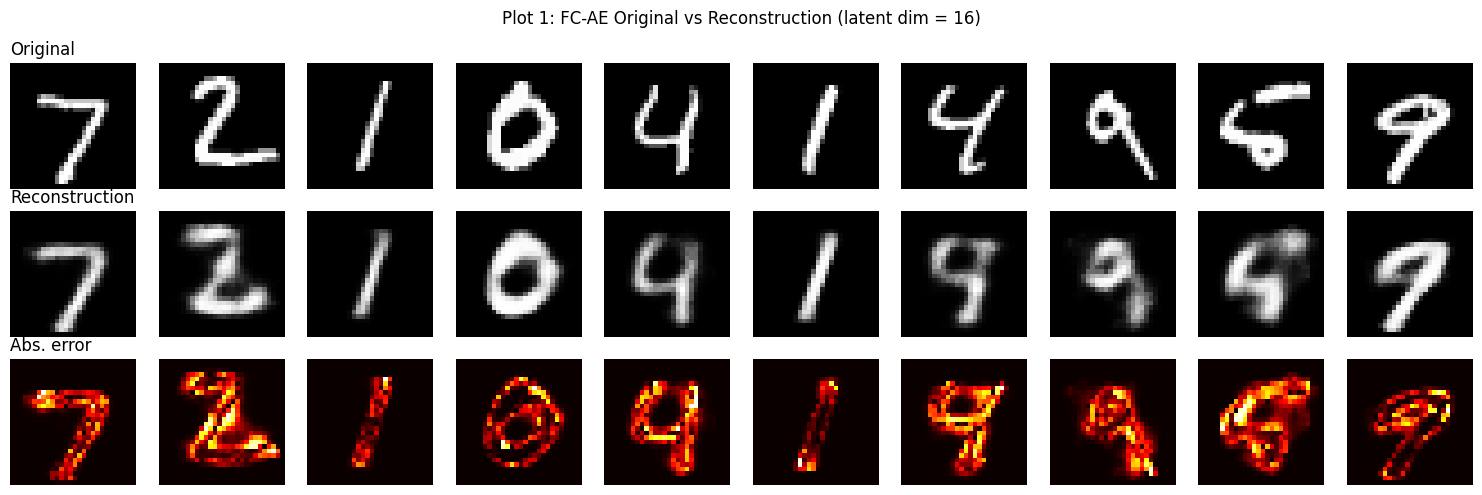

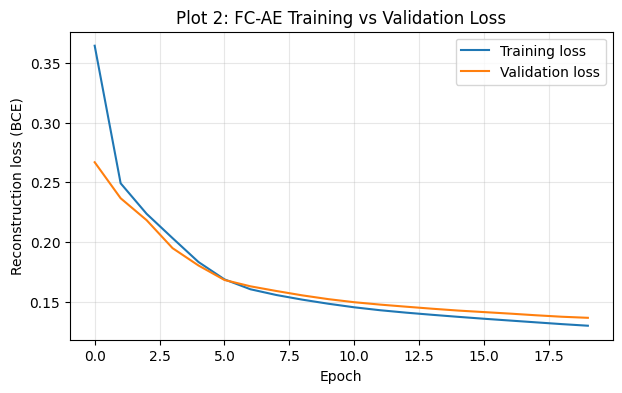

Final train loss: 0.1297
Final val loss  : 0.1363


In [2]:
# ===== Step 2: Fully Connected Autoencoder =====

# Dictionary to collect results for the consolidated table later
results = {}

def build_fc_ae(latent_dim=16):
    inp = Input(shape=(784,), name="input")
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(32, activation="relu")(x)
    z = layers.Dense(latent_dim, activation="relu", name="latent")(x)
    x = layers.Dense(32, activation="relu")(z)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(784, activation="sigmoid", name="output")(x)
    return Model(inp, out, name=f"fc_ae_{latent_dim}")

fc_ae = build_fc_ae(latent_dim=16)
fc_ae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss="binary_crossentropy")
fc_ae.summary()

# ---- Train (validation split keeps the test set truly unseen) ----
start = time.time()
history_fc = fc_ae.fit(
    x_train_flat, x_train_flat,       # input = target
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)
fc_time = time.time() - start
print(f"\nFC-AE training time: {fc_time:.1f} s")

# ---- Reconstruct test set ----
fc_recon = fc_ae.predict(x_test_flat, verbose=0)

# ---- Metrics (MSE, MAE, SSIM) ----
fc_mse, fc_mae, fc_ssim = evaluate_reconstruction(x_test_flat, fc_recon)
fc_params = fc_ae.count_params()

results["FC Autoencoder"] = dict(MSE=fc_mse, MAE=fc_mae, SSIM=fc_ssim,
                                 Params=fc_params, Time=fc_time)

print("\n--- FC Autoencoder Test Metrics ---")
print(f"Test MSE   : {fc_mse:.5f}")
print(f"Test MAE   : {fc_mae:.5f}")
print(f"Mean SSIM  : {fc_ssim:.4f}")
print(f"Parameters : {fc_params:,}")

# ---- Plot 1: Original vs Reconstruction (10 images) + error map ----
n = 10
fig, axes = plt.subplots(3, n, figsize=(15, 5))
for i in range(n):
    orig = x_test_flat[i].reshape(28, 28)
    rec  = fc_recon[i].reshape(28, 28)
    err  = np.abs(orig - rec)

    axes[0, i].imshow(orig, cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(rec,  cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(err,  cmap="hot");  axes[2, i].axis("off")
axes[0, 0].set_title("Original", loc="left")
axes[1, 0].set_title("Reconstruction", loc="left")
axes[2, 0].set_title("Abs. error", loc="left")
plt.suptitle("Plot 1: FC-AE Original vs Reconstruction (latent dim = 16)")
plt.tight_layout()
plt.show()

# ---- Plot 2: Training vs Validation loss ----
plt.figure(figsize=(7, 4))
plt.plot(history_fc.history["loss"], label="Training loss")
plt.plot(history_fc.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss (BCE)")
plt.title("Plot 2: FC-AE Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Final train loss: {history_fc.history['loss'][-1]:.4f}")
print(f"Final val loss  : {history_fc.history['val_loss'][-1]:.4f}")

Model: "cae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (MaxPooling2D)           │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 13s 156ms/step - loss: 0.2485 - val_loss: 0.1095
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - loss: 0.0937 - val_loss: 0.0891
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step - loss: 0.0835 - val_loss: 0.0824
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - loss: 0.0791 - val_loss: 0.0791
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 159ms/step - loss: 0.0766 - val_loss: 0.0771
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - loss: 0.0748 - val_loss: 0.0757
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - loss: 0.0737 - val_loss: 0.0748
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - loss: 0.0728 - val_loss: 0.0740
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - loss: 0.0721 - val_loss: 0.0734
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - loss: 0.0715 - val_loss: 0.0729
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - loss: 0.0709 - val_loss: 0.0722
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11

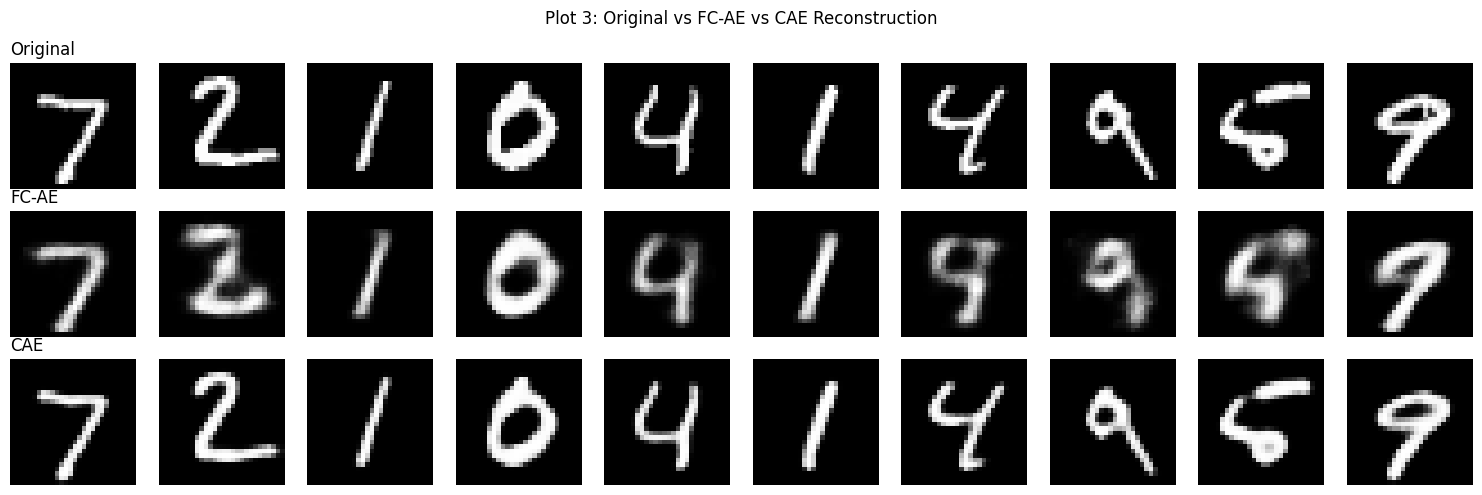

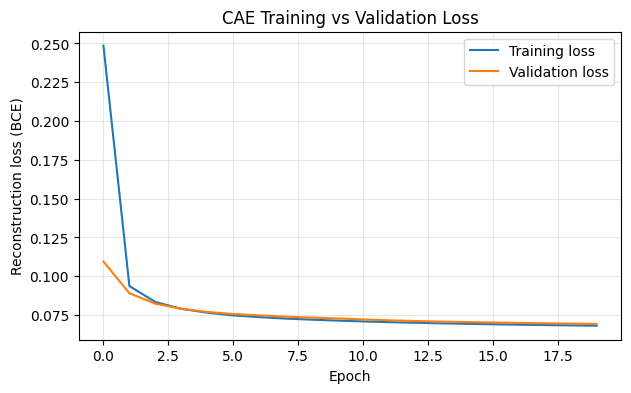

In [3]:
# ===== Step 3: Convolutional Autoencoder =====

def build_cae():
    inp = Input(shape=(28, 28, 1), name="input")

    # ---- Encoder ----
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)   # 28x28x32
    x = layers.MaxPooling2D(2, padding="same")(x)                      # 14x14x32
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)     # 14x14x64
    x = layers.MaxPooling2D(2, padding="same", name="latent")(x)       # 7x7x64  (latent map)

    # ---- Decoder ----
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)     # 7x7x64
    x = layers.UpSampling2D(2)(x)                                      # 14x14x64
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)     # 14x14x32
    x = layers.UpSampling2D(2)(x)                                      # 28x28x32
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same", name="output")(x)  # 28x28x1

    return Model(inp, out, name="cae")

cae = build_cae()
cae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss="binary_crossentropy")
cae.summary()

# ---- Train with the SAME protocol as the FC-AE (controlled comparison) ----
start = time.time()
history_cae = cae.fit(
    x_train_img, x_train_img,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)
cae_time = time.time() - start
print(f"\nCAE training time: {cae_time:.1f} s")

# ---- Reconstruct test set and evaluate ----
cae_recon = cae.predict(x_test_img, verbose=0)
cae_mse, cae_mae, cae_ssim = evaluate_reconstruction(x_test_img, cae_recon)
cae_params = cae.count_params()

results["Conv. Autoencoder"] = dict(MSE=cae_mse, MAE=cae_mae, SSIM=cae_ssim,
                                    Params=cae_params, Time=cae_time)

# ---- Comparison table: FC-AE vs CAE ----
print("\n" + "=" * 68)
print(f"{'Model':<22}{'MSE':>10}{'MAE':>10}{'SSIM':>10}{'Params':>12}")
print("-" * 68)
for name in ["FC Autoencoder", "Conv. Autoencoder"]:
    r = results[name]
    print(f"{name:<22}{r['MSE']:>10.5f}{r['MAE']:>10.5f}{r['SSIM']:>10.4f}{r['Params']:>12,}")
print("=" * 68)

# ---- Plot 3: Original -> FC-AE -> CAE (10 images) ----
n = 10
fig, axes = plt.subplots(3, n, figsize=(15, 5))
for i in range(n):
    axes[0, i].imshow(x_test[i], cmap="gray");                   axes[0, i].axis("off")
    axes[1, i].imshow(fc_recon[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(cae_recon[i].reshape(28, 28), cmap="gray");axes[2, i].axis("off")
axes[0, 0].set_title("Original", loc="left")
axes[1, 0].set_title("FC-AE", loc="left")
axes[2, 0].set_title("CAE", loc="left")
plt.suptitle("Plot 3: Original vs FC-AE vs CAE Reconstruction")
plt.tight_layout()
plt.show()

# ---- (Optional but useful) CAE training curves ----
plt.figure(figsize=(7, 4))
plt.plot(history_cae.history["loss"], label="Training loss")
plt.plot(history_cae.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Reconstruction loss (BCE)")
plt.title("CAE Training vs Validation Loss")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 165ms/step - loss: 0.2637 - val_loss: 0.1303
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 159ms/step - loss: 0.1101 - val_loss: 0.1016
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step - loss: 0.0953 - val_loss: 0.0940
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step - loss: 0.0907 - val_loss: 0.0905
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step - loss: 0.0872 - val_loss: 0.0877
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - loss: 0.0852 - val_loss: 0.0857
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step - loss: 0.0834 - val_loss: 0.0845
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 166ms/step - loss: 0.0823 - val_loss: 0.0832
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - loss: 0.0813 - val_loss: 0.0823
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 162ms/step - loss: 0.0804 - val_loss: 0.0815
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 162ms/step - loss: 0.0797 - val_loss: 0.0809
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 12

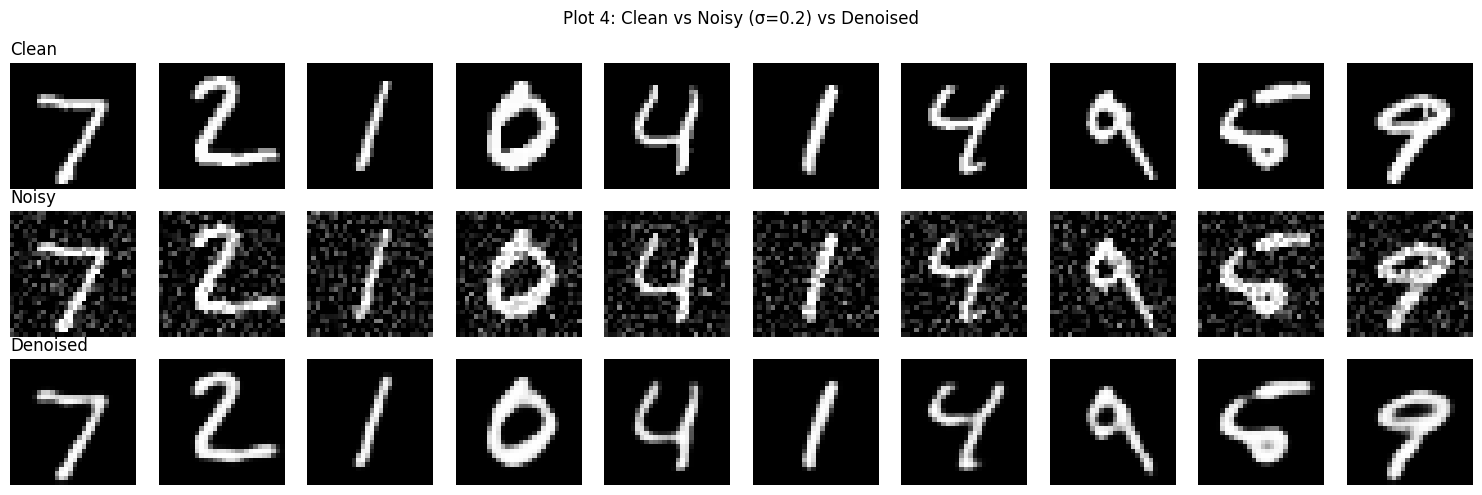

sigma=0.1 -> MSE=0.00329, MAE=0.01739, SSIM=0.9629
sigma=0.2 -> MSE=0.00462, MAE=0.02110, SSIM=0.9451
sigma=0.3 -> MSE=0.00708, MAE=0.02719, SSIM=0.9148

Noise Level           MSE       MAE      SSIM
--------------------------------------------------
0.1               0.00329   0.01739    0.9629
0.2               0.00462   0.02110    0.9451
0.3               0.00708   0.02719    0.9148


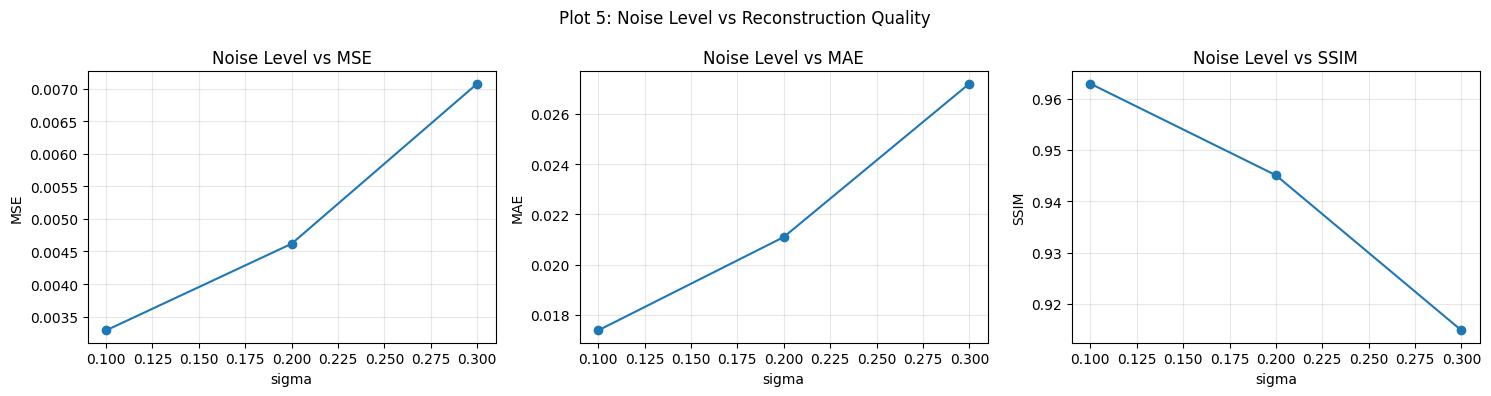

Salt-and-pepper p=0.05 -> MSE=0.00575, MAE=0.02308, SSIM=0.9237
Salt-and-pepper p=0.1 -> MSE=0.00819, MAE=0.02893, SSIM=0.8809
Salt-and-pepper p=0.2 -> MSE=0.01492, MAE=0.04343, SSIM=0.7564


In [4]:
# ===== Step 4: Denoising Autoencoder =====

# ---- Noise functions ----
def add_gaussian_noise(images, sigma):
    noisy = images + np.random.normal(0, sigma, images.shape)
    return np.clip(noisy, 0.0, 1.0)

def add_salt_and_pepper_noise(images, p):
    noisy = images.copy()
    mask = np.random.rand(*images.shape)
    noisy[mask < (p / 2)] = 0.0        # pepper
    noisy[mask > 1 - (p / 2)] = 1.0    # salt
    return noisy

# ---- Build training data: corrupt images, but target stays clean ----
# Use one representative noise level for the main training run
GAUSSIAN_SIGMA_TRAIN = 0.2

x_train_noisy = add_gaussian_noise(x_train_img, GAUSSIAN_SIGMA_TRAIN)
x_test_noisy  = add_gaussian_noise(x_test_img, GAUSSIAN_SIGMA_TRAIN)

# ---- Denoising CAE: same architecture as the CAE ----
def build_denoising_cae():
    inp = Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    return Model(inp, out, name="denoising_cae")

dae = build_denoising_cae()
dae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss="binary_crossentropy")

start = time.time()
history_dae = dae.fit(
    x_train_noisy, x_train_img,        # input = noisy, target = clean
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)
dae_time = time.time() - start
print(f"\nDenoising CAE training time: {dae_time:.1f} s")

# ---- Evaluate on the main test noise level ----
dae_recon = dae.predict(x_test_noisy, verbose=0)
dae_mse, dae_mae, dae_ssim = evaluate_reconstruction(x_test_img, dae_recon)
dae_params = dae.count_params()

results["Denoising CAE"] = dict(MSE=dae_mse, MAE=dae_mae, SSIM=dae_ssim,
                                Params=dae_params, Time=dae_time)

print(f"Denoising CAE (sigma={GAUSSIAN_SIGMA_TRAIN}) -> MSE={dae_mse:.5f}, "
      f"MAE={dae_mae:.5f}, SSIM={dae_ssim:.4f}")

# ---- Plot 4: Clean vs Noisy vs Denoised (10 images) ----
n = 10
fig, axes = plt.subplots(3, n, figsize=(15, 5))
for i in range(n):
    axes[0, i].imshow(x_test_img[i].squeeze(), cmap="gray");   axes[0, i].axis("off")
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(dae_recon[i].squeeze(), cmap="gray");    axes[2, i].axis("off")
axes[0, 0].set_title("Clean", loc="left")
axes[1, 0].set_title("Noisy", loc="left")
axes[2, 0].set_title("Denoised", loc="left")
plt.suptitle(f"Plot 4: Clean vs Noisy (σ={GAUSSIAN_SIGMA_TRAIN}) vs Denoised")
plt.tight_layout()
plt.show()

# ---- Plot 5: Noise level vs Reconstruction Quality ----
# Train a separate model at each Gaussian noise level for a fair sweep
gaussian_levels = [0.1, 0.2, 0.3]
noise_results = {}

for sigma in gaussian_levels:
    xtr_noisy = add_gaussian_noise(x_train_img, sigma)
    xte_noisy = add_gaussian_noise(x_test_img, sigma)

    model = build_denoising_cae()
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss="binary_crossentropy")
    model.fit(xtr_noisy, x_train_img, epochs=20, batch_size=128,
              validation_split=0.1, shuffle=True, verbose=0)

    recon = model.predict(xte_noisy, verbose=0)
    mse, mae, ssim_val = evaluate_reconstruction(x_test_img, recon)
    noise_results[sigma] = dict(MSE=mse, MAE=mae, SSIM=ssim_val)
    print(f"sigma={sigma} -> MSE={mse:.5f}, MAE={mae:.5f}, SSIM={ssim_val:.4f}")

# ---- Report table ----
print("\n" + "=" * 50)
print(f"{'Noise Level':<15}{'MSE':>10}{'MAE':>10}{'SSIM':>10}")
print("-" * 50)
for sigma, r in noise_results.items():
    print(f"{sigma:<15}{r['MSE']:>10.5f}{r['MAE']:>10.5f}{r['SSIM']:>10.4f}")
print("=" * 50)

# ---- Plot: Noise level vs metrics (separate axes, as the manual requires) ----
sigmas = list(noise_results.keys())
mses  = [noise_results[s]["MSE"] for s in sigmas]
maes  = [noise_results[s]["MAE"] for s in sigmas]
ssims = [noise_results[s]["SSIM"] for s in sigmas]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(sigmas, mses, marker="o");  axes[0].set_title("Noise Level vs MSE");  axes[0].set_xlabel("sigma"); axes[0].set_ylabel("MSE")
axes[1].plot(sigmas, maes, marker="o");  axes[1].set_title("Noise Level vs MAE");  axes[1].set_xlabel("sigma"); axes[1].set_ylabel("MAE")
axes[2].plot(sigmas, ssims, marker="o"); axes[2].set_title("Noise Level vs SSIM"); axes[2].set_xlabel("sigma"); axes[2].set_ylabel("SSIM")
for ax in axes: ax.grid(alpha=0.3)
plt.suptitle("Plot 5: Noise Level vs Reconstruction Quality")
plt.tight_layout()
plt.show()

# ---- Bonus: Salt-and-pepper comparison (Additional Exercise 2) ----
p_levels = [0.05, 0.10, 0.20]
sp_results = {}
for p in p_levels:
    xte_sp = add_salt_and_pepper_noise(x_test_img, p)
    recon = dae.predict(xte_sp, verbose=0)  # reuse the Gaussian-trained model to compare robustness
    mse, mae, ssim_val = evaluate_reconstruction(x_test_img, recon)
    sp_results[p] = dict(MSE=mse, MAE=mae, SSIM=ssim_val)
    print(f"Salt-and-pepper p={p} -> MSE={mse:.5f}, MAE={mae:.5f}, SSIM={ssim_val:.4f}")

In [5]:
print(4)

4


In [6]:
# ===== Step 5: Variational Autoencoder =====

LATENT_DIM_VAE = 2  # small so it can be visualized directly (Section 17)

# ---- Sampling layer: implements z = mu + sigma * epsilon ----
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# ---- Encoder ----
encoder_inputs = Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)  # 14x14x32
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)               # 7x7x64
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM_VAE, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM_VAE, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

vae_encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="vae_encoder")
vae_encoder.summary()

# ---- Decoder ----
latent_inputs = Input(shape=(LATENT_DIM_VAE,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)  # 14x14x64
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)  # 28x28x32
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)  # 28x28x1

vae_decoder = Model(latent_inputs, decoder_outputs, name="vae_decoder")
vae_decoder.summary()

# ---- Full VAE model with custom train_step (handles the combined loss) ----
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction loss (BCE, summed over pixels, averaged over batch)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )
            # KL divergence: -0.5 * sum(1 + log_var - mu^2 - var)
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

# ---- Build, compile, train ----
vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

start = time.time()
history_vae = vae.fit(
    x_train_img,
    epochs=30,                 # VAEs often need a few more epochs than plain AEs
    batch_size=128,
    validation_data=(x_test_img, None),
    shuffle=True,
    verbose=1
)
vae_time = time.time() - start
print(f"\nVAE training time: {vae_time:.1f} s")

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - kl_loss: 0.2871 - loss: 322.6953 - reconstruction_loss: 322.4082 - val_kl_loss: 0.7953 - val_loss: 201.3260 - val_reconstruction_loss: 200.5307
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - kl_loss: 1.3663 - loss: 209.6856 - reconstruction_loss: 208.3194 - val_kl_loss: 2.6870 - val_loss: 193.7012 - val_reconstruction_loss: 191.0142
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - kl_loss: 2.8539 - loss: 201.9668 - reconstruction_loss: 199.1129 - val_kl_loss: 3.3152 - val_loss: 188.4138 - val_reconstruction_loss: 185.0986
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - kl_loss: 3.1288 - loss: 199.2108 - reconstruction_loss: 196.0820 - val_kl_loss: 2.9027 - val_loss: 188.5215 - val_reconstruction_loss: 185.6188
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - kl_loss: 3.2090 - loss: 197.1938 - reconstruction_loss: 193.9848 - val_kl_loss: 3.5418 - val_loss: 187.0122 - val_reconstruction_loss: 183.4704
Epoch 6/30
79

--- VAE Metrics ---
Reconstruction Loss : 177.6049
KL Loss             : 3.4620
Total Loss          : 181.0669
Test MSE            : 0.05441
Test MAE            : 0.12745
Mean SSIM           : 0.3185
Parameters          : 134,165


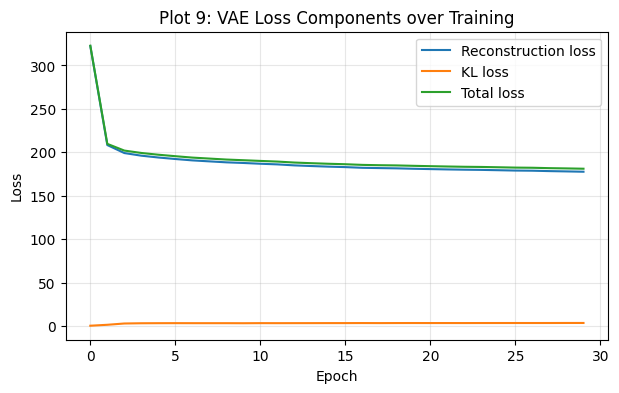

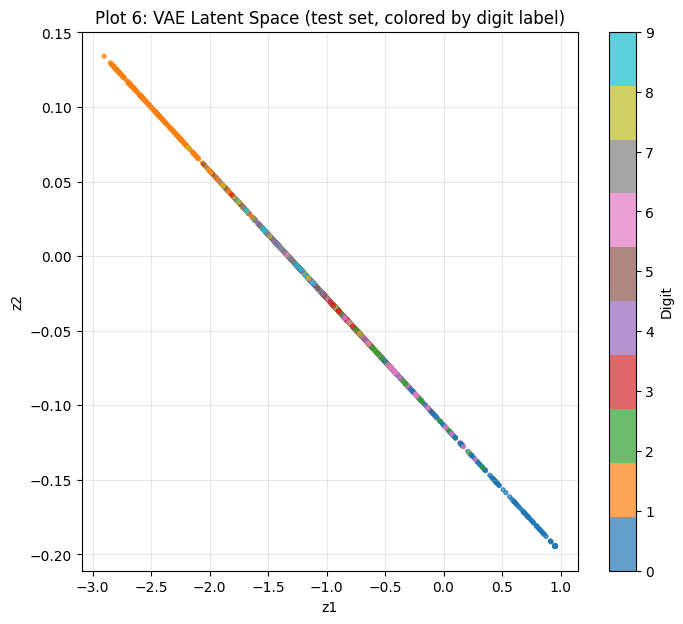

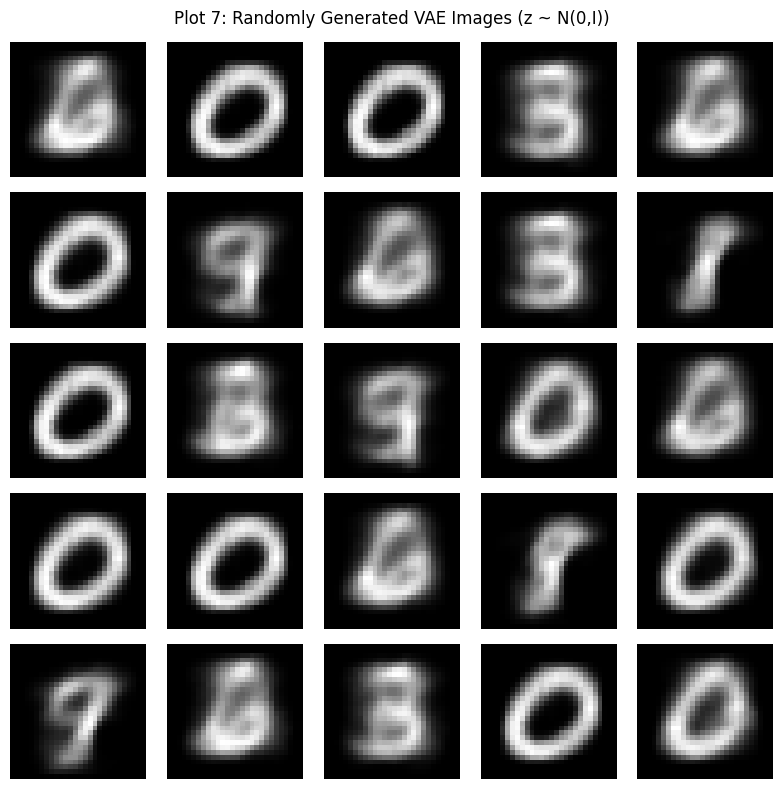

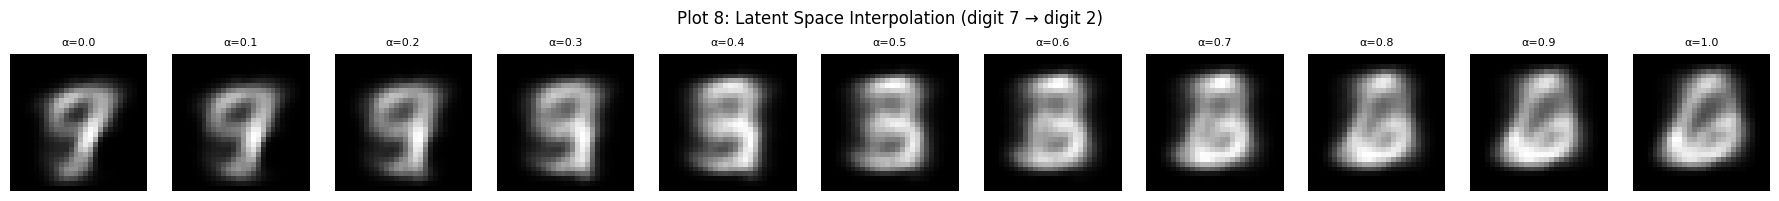

Interpolating between test image 0 (digit 7) and test image 1 (digit 2)


In [7]:
# ===== Step 6: VAE Evaluation =====

# ---- Reconstruction on test set ----
z_mean_test, z_log_var_test, z_test = vae_encoder.predict(x_test_img, verbose=0)
vae_recon = vae_decoder.predict(z_mean_test, verbose=0)  # use mean (not sampled) for evaluation

vae_mse, vae_mae, vae_ssim = evaluate_reconstruction(x_test_img, vae_recon)
vae_params = vae_encoder.count_params() + vae_decoder.count_params()

# Get final loss components from training history
final_recon_loss = history_vae.history["reconstruction_loss"][-1]
final_kl_loss = history_vae.history["kl_loss"][-1]
final_total_loss = history_vae.history["loss"][-1]

results["VAE"] = dict(MSE=vae_mse, MAE=vae_mae, SSIM=vae_ssim,
                      Params=vae_params, Time=vae_time)

print("--- VAE Metrics ---")
print(f"Reconstruction Loss : {final_recon_loss:.4f}")
print(f"KL Loss             : {final_kl_loss:.4f}")
print(f"Total Loss          : {final_total_loss:.4f}")
print(f"Test MSE            : {vae_mse:.5f}")
print(f"Test MAE            : {vae_mae:.5f}")
print(f"Mean SSIM           : {vae_ssim:.4f}")
print(f"Parameters          : {vae_params:,}")

# ---- Plot 9: VAE Training/Validation Reconstruction Loss ----
plt.figure(figsize=(7, 4))
plt.plot(history_vae.history["reconstruction_loss"], label="Reconstruction loss")
plt.plot(history_vae.history["kl_loss"], label="KL loss")
plt.plot(history_vae.history["loss"], label="Total loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Plot 9: VAE Loss Components over Training")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# ---- Plot 6: VAE Latent Space (colored by digit label) ----
plt.figure(figsize=(8, 7))
scatter = plt.scatter(z_mean_test[:, 0], z_mean_test[:, 1], c=y_test, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, label="Digit")
plt.xlabel("z1"); plt.ylabel("z2")
plt.title("Plot 6: VAE Latent Space (test set, colored by digit label)")
plt.grid(alpha=0.3)
plt.show()

# ---- Plot 7: Randomly Generated Images ----
n_generate = 25
random_latents = np.random.normal(0, 1, size=(n_generate, LATENT_DIM_VAE))
generated = vae_decoder.predict(random_latents, verbose=0)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap="gray")
    ax.axis("off")
plt.suptitle("Plot 7: Randomly Generated VAE Images (z ~ N(0,I))")
plt.tight_layout()
plt.show()

# ---- Plot 8: Latent Space Interpolation ----
# Pick two real test images of different digits as endpoints
idx_a, idx_b = 0, 1
# Find two images with different labels for a more interesting interpolation
for i in range(len(y_test)):
    if y_test[i] != y_test[idx_a]:
        idx_b = i
        break

z_A = z_mean_test[idx_a]
z_B = z_mean_test[idx_b]

alphas = np.linspace(0, 1, 11)  # 0, 0.1, ..., 1.0
z_interp = np.array([(1 - a) * z_A + a * z_B for a in alphas])
decoded_interp = vae_decoder.predict(z_interp, verbose=0)

fig, axes = plt.subplots(1, len(alphas), figsize=(18, 2))
for i, ax in enumerate(axes):
    ax.imshow(decoded_interp[i].squeeze(), cmap="gray")
    ax.set_title(f"α={alphas[i]:.1f}", fontsize=8)
    ax.axis("off")
plt.suptitle(f"Plot 8: Latent Space Interpolation (digit {y_test[idx_a]} → digit {y_test[idx_b]})")
plt.tight_layout()
plt.show()

print(f"Interpolating between test image {idx_a} (digit {y_test[idx_a]}) "
      f"and test image {idx_b} (digit {y_test[idx_b]})")

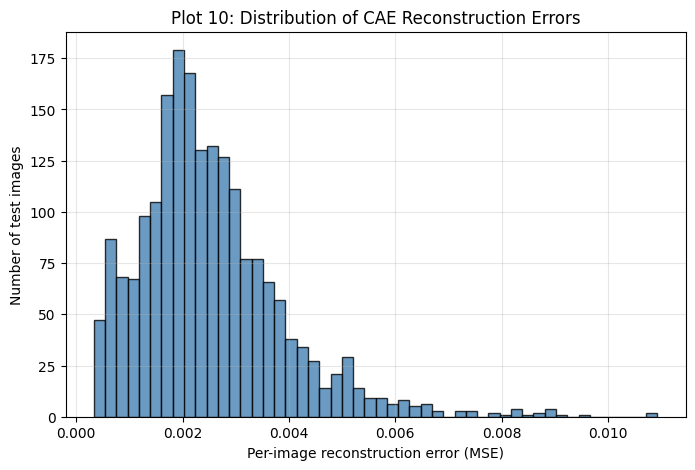

Mean error   : 0.00252
Median error : 0.00229
Std dev      : 0.00138
Min / Max    : 0.00033 / 0.01093


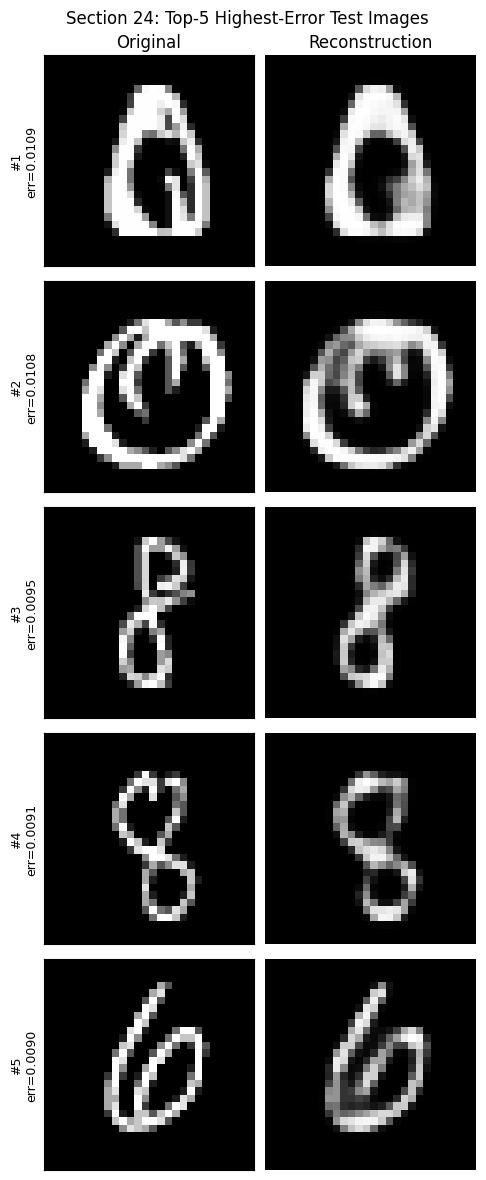

Top-5 highest-error test images:
  Sample 1: index=895, digit=0, error=0.01093
  Sample 2: index=1526, digit=0, error=0.01076
  Sample 3: index=1320, digit=8, error=0.00947
  Sample 4: index=1855, digit=8, error=0.00910
  Sample 5: index=1969, digit=6, error=0.00900

Model                        MSE       MAE      SSIM      Params   Time(s)
------------------------------------------------------------------------------
FC Autoencoder           0.02403   0.06262    0.7116     211,040      13.0
Conv. Autoencoder        0.00252   0.01482    0.9746      74,497     223.9
Denoising CAE            0.00514   0.02247    0.9393      74,497     232.4
VAE                      0.05441   0.12745    0.3185     134,165     209.4


In [8]:
# ===== Step 7: Error Distribution and High-Error Analysis =====

# ---- Per-image reconstruction error (using the CAE, the best deterministic model) ----
def per_image_mse(originals, reconstructions):
    o = originals.reshape(len(originals), -1)
    r = reconstructions.reshape(len(reconstructions), -1)
    return np.mean((o - r) ** 2, axis=1)

errors_cae = per_image_mse(x_test_img, cae_recon)

# ---- Plot 10: Distribution of Reconstruction Errors ----
plt.figure(figsize=(8, 5))
plt.hist(errors_cae, bins=50, color="steelblue", edgecolor="black", alpha=0.8)
plt.xlabel("Per-image reconstruction error (MSE)")
plt.ylabel("Number of test images")
plt.title("Plot 10: Distribution of CAE Reconstruction Errors")
plt.grid(alpha=0.3)
plt.show()

print(f"Mean error   : {errors_cae.mean():.5f}")
print(f"Median error : {np.median(errors_cae):.5f}")
print(f"Std dev      : {errors_cae.std():.5f}")
print(f"Min / Max    : {errors_cae.min():.5f} / {errors_cae.max():.5f}")

# ---- Section 24: Top-5 highest-error images ----
top5_idx = np.argsort(errors_cae)[-5:][::-1]  # descending order

fig, axes = plt.subplots(5, 2, figsize=(5, 12))
for row, idx in enumerate(top5_idx):
    axes[row, 0].imshow(x_test_img[idx].squeeze(), cmap="gray")
    axes[row, 0].set_ylabel(f"#{row+1}\nerr={errors_cae[idx]:.4f}", fontsize=9)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

    axes[row, 1].imshow(cae_recon[idx].squeeze(), cmap="gray")
    axes[row, 1].axis("off")

axes[0, 0].set_title("Original")
axes[0, 1].set_title("Reconstruction")
plt.suptitle("Section 24: Top-5 Highest-Error Test Images")
plt.tight_layout()
plt.show()

print("Top-5 highest-error test images:")
for row, idx in enumerate(top5_idx):
    print(f"  Sample {row+1}: index={idx}, digit={y_test[idx]}, error={errors_cae[idx]:.5f}")

# ---- Section 25: Consolidated Results Table ----
print("\n" + "=" * 78)
print(f"{'Model':<22}{'MSE':>10}{'MAE':>10}{'SSIM':>10}{'Params':>12}{'Time(s)':>10}")
print("-" * 78)
for name, r in results.items():
    print(f"{name:<22}{r['MSE']:>10.5f}{r['MAE']:>10.5f}{r['SSIM']:>10.4f}{r['Params']:>12,}{r['Time']:>10.1f}")
print("=" * 78)

Latent dim=  2 -> MSE=0.04835, MAE=0.11388, SSIM=0.4268, Params=210,130
Latent dim=  8 -> MSE=0.02846, MAE=0.07195, SSIM=0.6648, Params=210,520
Latent dim= 16 -> MSE=0.02299, MAE=0.06046, SSIM=0.7261, Params=211,040
Latent dim= 32 -> MSE=0.02128, MAE=0.05616, SSIM=0.7478, Params=212,080

Latent Dim         MSE      SSIM         Params
------------------------------------------------------------
2              0.04835    0.4268        210,130
8              0.02846    0.6648        210,520
16             0.02299    0.7261        211,040
32             0.02128    0.7478        212,080


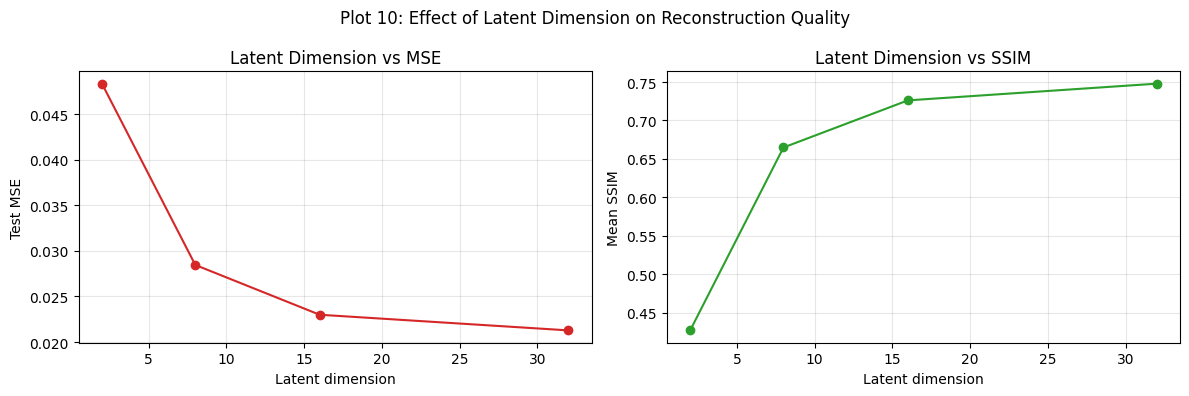

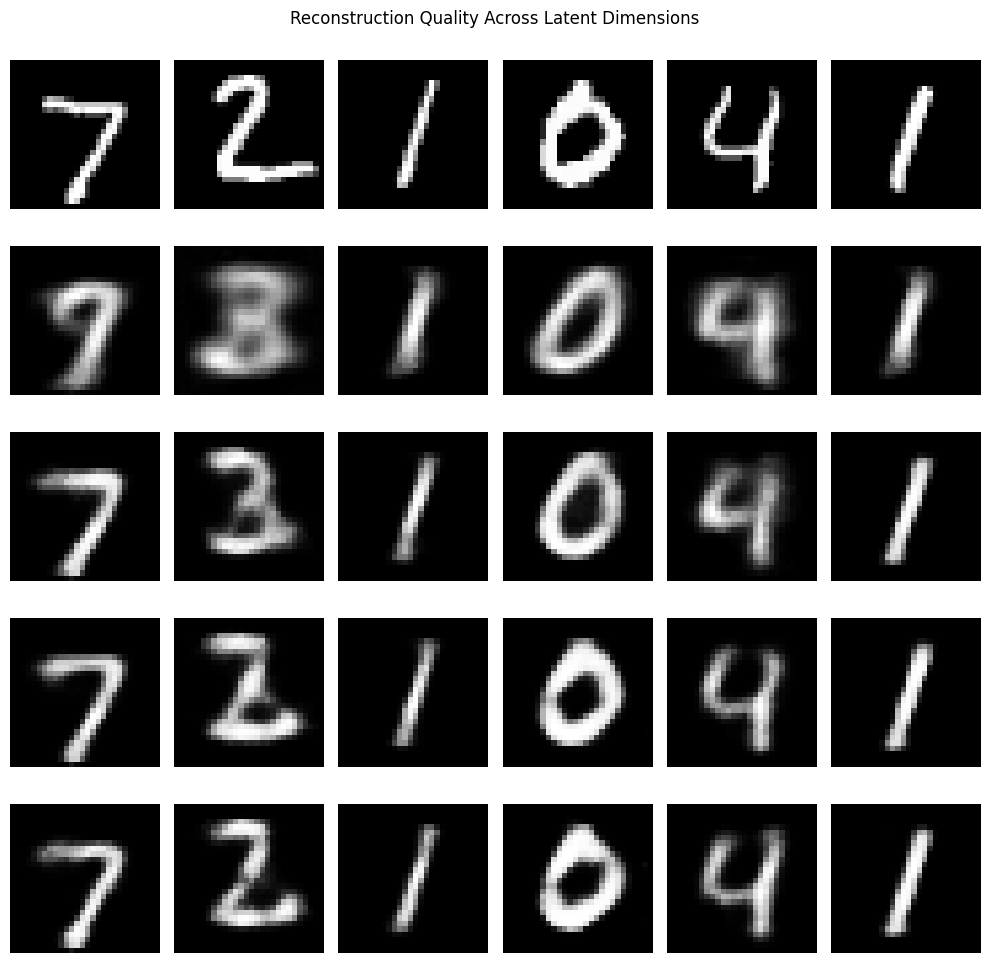

In [9]:
# ===== Step 8: Latent Dimension Study =====

latent_dims = [2, 8, 16, 32]
dim_results = {}

for dim in latent_dims:
    model = build_fc_ae(latent_dim=dim)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss="binary_crossentropy")

    model.fit(
        x_train_flat, x_train_flat,
        epochs=20,
        batch_size=128,
        validation_split=0.1,
        shuffle=True,
        verbose=0
    )

    recon = model.predict(x_test_flat, verbose=0)
    mse, mae, ssim_val = evaluate_reconstruction(x_test_flat, recon)
    params = model.count_params()

    dim_results[dim] = dict(MSE=mse, MAE=mae, SSIM=ssim_val, Params=params)
    print(f"Latent dim={dim:>3} -> MSE={mse:.5f}, MAE={mae:.5f}, "
          f"SSIM={ssim_val:.4f}, Params={params:,}")

# ---- Report table ----
print("\n" + "=" * 60)
print(f"{'Latent Dim':<12}{'MSE':>10}{'SSIM':>10}{'Params':>15}")
print("-" * 60)
for dim, r in dim_results.items():
    print(f"{dim:<12}{r['MSE']:>10.5f}{r['SSIM']:>10.4f}{r['Params']:>15,}")
print("=" * 60)

# ---- Plot 10 (Section 27): Latent Dimension vs Reconstruction MSE ----
dims = list(dim_results.keys())
mses = [dim_results[d]["MSE"] for d in dims]
ssims = [dim_results[d]["SSIM"] for d in dims]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(dims, mses, marker="o", color="tab:red")
axes[0].set_xlabel("Latent dimension"); axes[0].set_ylabel("Test MSE")
axes[0].set_title("Latent Dimension vs MSE")
axes[0].grid(alpha=0.3)

axes[1].plot(dims, ssims, marker="o", color="tab:green")
axes[1].set_xlabel("Latent dimension"); axes[1].set_ylabel("Mean SSIM")
axes[1].set_title("Latent Dimension vs SSIM")
axes[1].grid(alpha=0.3)

plt.suptitle("Plot 10: Effect of Latent Dimension on Reconstruction Quality")
plt.tight_layout()
plt.show()

# ---- Optional: visual comparison across latent dims for a few images ----
fig, axes = plt.subplots(len(latent_dims) + 1, 6, figsize=(10, 2 * (len(latent_dims)+1)))
for j in range(6):
    axes[0, j].imshow(x_test[j], cmap="gray")
    axes[0, j].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=9)

for i, dim in enumerate(latent_dims):
    model = build_fc_ae(latent_dim=dim)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
    model.fit(x_train_flat, x_train_flat, epochs=20, batch_size=128, verbose=0)
    recon = model.predict(x_test_flat[:6], verbose=0)
    for j in range(6):
        axes[i+1, j].imshow(recon[j].reshape(28,28), cmap="gray")
        axes[i+1, j].axis("off")
    axes[i+1, 0].set_ylabel(f"dz={dim}", fontsize=9)
plt.suptitle("Reconstruction Quality Across Latent Dimensions")
plt.tight_layout()
plt.show()